Name:Refael shpigelman 211667639 Alesia akolenko 321868069

Overview

The goal of this project is to predict Emergency Department (ED) overcrowding using historical hospital data.
The system analyzes time-based patterns in patient flow and uses machine learning models to forecast future workload levels.

Data Description

The dataset includes:

Timestamps of events
Department names
Room identifiers
Requirement descriptions
Status values

The data represents operational activity in the Emergency Department over time.

data load

In [ ]:
from google.colab import files
uploaded = files.upload()

Imports + Mappings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DEPARTMENT_MAPPING = {
    "מיון כירורגיה - מ.הלכים": "Surgery_Walking",
    "מיון פנימי": "Internal",
    "A": "Area_A",
    "טראומה חדש": "New_Trauma",
    "מלר\"ד אגף מהלכים": "ED_Walking_Wing",
    "C": "Area_C",
    "B": "Area_B",
    "טריאז' מיון חדש": "New_ED_Triage",
    "מלרד טראומה בנין 16": "ED_Trauma_Building_16",
    "מלרד מהלכים בנין 16": "ED_Walking_Building_16",
    "A מלרד אגף": "Area_A_ED_Wing",
    "מיון כירורגי": "Surgical_ED",
    "מיון אורתופדי": "Orthopedic_ED",
    "המחלקה לרפואה דחופה": "Emergency_Medicine_Department",
    "B מלרד אגף": "Area_B_ED_Wing",
    "מיון מהלכים": "Walking_ED",
    "דימות": "Imaging",
    "C מלרד אגף": "Area_C_ED_Wing",
    "מיון פנימי - לא פעיל": "Internal_Inactive",
    "מיון כירורגי - לא פעיל": "Surgical_Inactive",
    "מיון מהלכים - לא פעיל": "Walking_Inactive",
    "מיון אורתופדי - לא פעיל": "Orthopedic_Inactive",
    "המחלקה לרפואה דחופה - לא פעיל": "Emergency_Medicine_Inactive",
    "חדר צוות": "Staff_Room",
    "משרד קבלה": "Reception_Office",
    "חדר סמינרים": "Seminar_Room",
    "מיון כירורגי ישן": "Old_Surgical_ED",
    "מלרד טראומה": "ED_Trauma",
    "מלרד מהלכים": "ED_Walking",
    "D מלרד מהלכים": "Area_D_ED_Walking",
    "מיון פנימי ישן": "Old_Internal_ED",
    "חדר הלם": "Shock_Room",
    "מחסן שוכבים": "Patient_Storage"
}

STATUS_MAPPING = {
    "not_required": 0,
    "required": 1,
    "in_progress": 2,
    "partial": 3,
    "satisfied": 4,
    "taken": 5,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5
}

Define All Functions

In [2]:
def load_data(csv_path: str) -> pd.DataFrame:
    return pd.read_csv(csv_path)


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and transform the ED dataset for modeling."""
    data = df.copy()

    data = data.drop_duplicates()

    data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce", utc=True)
    data = data.dropna(subset=["timestamp"])

    data["department_en"] = data["department"].map(DEPARTMENT_MAPPING).fillna("Unknown")
    data["status_num"] = data["status"].astype(str).map(STATUS_MAPPING).fillna(-1).astype(int)

    data["hour"] = data["timestamp"].dt.hour
    data["day_of_week"] = data["timestamp"].dt.dayofweek
    data["month"] = data["timestamp"].dt.month
    data["is_weekend"] = data["day_of_week"].isin([4, 5]).astype(int)

    return data


def create_hourly_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate records hourly to create the prediction target:
    number of ED records/events per hour.
    """
    hourly = (
        df.set_index("timestamp")
          .groupby(pd.Grouper(freq="h"))
          .agg(
              arrivals=("status_num", "size"),
              avg_status=("status_num", "mean")
          )
          .dropna()
          .reset_index()
    )

    hourly["hour"] = hourly["timestamp"].dt.hour
    hourly["day_of_week"] = hourly["timestamp"].dt.dayofweek
    hourly["month"] = hourly["timestamp"].dt.month
    hourly["is_weekend"] = hourly["day_of_week"].isin([4, 5]).astype(int)

    hourly["arrivals_lag_1"] = hourly["arrivals"].shift(1)
    hourly["arrivals_lag_2"] = hourly["arrivals"].shift(2)
    hourly["arrivals_roll_3"] = hourly["arrivals"].rolling(3).mean()
    hourly["arrivals_roll_6"] = hourly["arrivals"].rolling(6).mean()

    hourly = hourly.dropna().reset_index(drop=True)
    return hourly

In [3]:
csv_path = "ED_full_data_2.csv"

df = load_data(csv_path)

print("Shape:", df.shape)
display(df.head())
print(df.info())
print(df.isnull().sum())

Shape: (463897, 5)
                       timestamp  ...     status
0     2023-11-08 08:12:03.787+00  ...          4
1     2023-11-08 08:12:03.787+00  ...          3
2  2024-03-18 10:08:57.218644+00  ...  satisfied
3  2024-03-18 10:08:58.083959+00  ...   required
4  2024-03-18 13:54:53.606752+00  ...  satisfied

[5 rows x 5 columns]
<class 'pandas.DataFrame'>
RangeIndex: 463897 entries, 0 to 463896
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   timestamp    463897 non-null  str  
 1   department   463897 non-null  str  
 2   room         463897 non-null  str  
 3   requirement  463897 non-null  str  
 4   status       463296 non-null  str  
dtypes: str(5)
memory usage: 17.7 MB
None
timestamp        0
department       0
room             0
requirement      0
status         601
dtype: int64


Run Preprocessing

In [4]:
clean_df = preprocess_data(df)

print("Shape after preprocessing:", clean_df.shape)
display(clean_df.head())

display(clean_df[["department", "department_en"]].drop_duplicates().head(30))
display(clean_df[["status", "status_num"]].drop_duplicates().sort_values("status_num"))

Shape after preprocessing: (403854, 11)
                         timestamp               department  ... month is_weekend
0 2023-11-08 08:12:03.787000+00:00  מיון כירורגיה - מ.הלכים  ...    11          0
1 2023-11-08 08:12:03.787000+00:00               מיון פנימי  ...    11          0
2 2024-03-18 10:08:57.218644+00:00                        A  ...     3          0
3 2024-03-18 10:08:58.083959+00:00                        A  ...     3          0
4 2024-03-18 13:54:53.606752+00:00               טראומה חדש  ...     3          0

[5 rows x 11 columns]
                     department     department_en
0       מיון כירורגיה - מ.הלכים   Surgery_Walking
1                    מיון פנימי          Internal
2                             A            Area_A
4                    טראומה חדש        New_Trauma
27             מלר"ד אגף מהלכים   ED_Walking_Wing
190                           C            Area_C
199                           B            Area_B
273             טריאז' מיון חדש     New_ED_Tr

Hourly Dataset Creation

To enable workload prediction, the event-level data was aggregated into hourly observations.
Each row represents a single hour in the emergency department.

In [5]:
hourly_df = create_hourly_target(clean_df)

print("Hourly dataset shape:", hourly_df.shape)
display(hourly_df.head())
display(hourly_df.describe())

Hourly dataset shape: (5275, 11)
                  timestamp  arrivals  ...  arrivals_roll_3  arrivals_roll_6
0 2024-04-16 07:00:00+00:00         8  ...         7.000000         8.000000
1 2024-04-16 08:00:00+00:00        20  ...        13.000000        11.000000
2 2024-04-16 09:00:00+00:00         6  ...        11.333333        11.666667
3 2024-04-17 10:00:00+00:00         6  ...        10.666667         8.833333
4 2024-04-17 11:00:00+00:00         5  ...         5.666667         9.333333

[5 rows x 11 columns]
          arrivals   avg_status  ...  arrivals_roll_3  arrivals_roll_6
count  5275.000000  5275.000000  ...      5275.000000      5275.000000
mean     76.552417     2.291812  ...        76.546603        76.531027
std      31.268069     0.298667  ...        26.351098        23.610367
min       1.000000     1.000000  ...         1.333333         1.833333
25%      57.000000     2.112430  ...        60.333333        62.333333
50%      76.000000     2.285714  ...        77.666667   

Simple EDA Graphs

In [6]:
clean_df = clean_df.sort_values(["room", "timestamp"])

In [7]:
room_requests = (
    clean_df[clean_df["status"].astype(str) == "required"]
    .groupby("room")
    .size()
    .sort_values(ascending=False)
)

room_requests.head(20)

In [8]:
cleaning_events = clean_df[
    clean_df["status"].astype(str).isin(
        ["required", "satisfied", "taken"]
    )
].copy()

cleaning_events = cleaning_events.sort_values(
    ["room", "timestamp"]
)

In [9]:
cleaning_times = []

for room, group in cleaning_events.groupby("room"):

    open_request = None

    for _, row in group.iterrows():

        status = str(row["status"])

        if status == "required":
            open_request = row["timestamp"]

        elif status in ["satisfied", "taken"]:

            if open_request is not None:

                duration = (
                    row["timestamp"] - open_request
                ).total_seconds() / 60

                cleaning_times.append({
                    "room": room,
                    "duration_minutes": duration
                })

                open_request = None

In [10]:
cleaning_df = clean_df[
    clean_df["requirement"].astype(str).str.contains("ניקיון", na=False)
].copy()

cleaning_df.shape
cleaning_requests = (
    cleaning_df[cleaning_df["status"] == "required"]
    .groupby("room")
    .size()
    .sort_values(ascending=False)
)

cleaning_requests.head(20)
plt.figure(figsize=(12,6))

cleaning_requests.head(15).plot(kind="bar")

plt.title("Rooms with Most Cleaning Requests")
plt.ylabel("Number of Requests")

plt.show()

זמן סגירת בקשת ניקיון

In [11]:
cleaning_df = cleaning_df.sort_values(
    ["room","timestamp"]
)

durations = []

for room, group in cleaning_df.groupby("room"):

    start_time = None

    for _, row in group.iterrows():

        if row["status"] == "required":
            start_time = row["timestamp"]

        elif row["status"] == "satisfied":

            if start_time is not None:

                duration = (
                    row["timestamp"] - start_time
                ).total_seconds() / 60

                durations.append({
                    "room": room,
                    "duration_minutes": duration
                })

                start_time = None

In [12]:
durations_df = pd.DataFrame(durations)

durations_df.describe()

In [13]:
durations_df["duration_minutes"].describe()

In [14]:
clean_durations_df = durations_df[
    durations_df["duration_minutes"] <= 120
].copy()

In [15]:
clean_durations_df["duration_minutes"].describe()

In [16]:
plt.figure(figsize=(10,6))

clean_durations_df["duration_minutes"].hist(
    bins=30
)

plt.title("Cleaning Completion Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")

plt.show()

In [17]:
room_cleaning_time = (
    clean_durations_df
    .groupby("room")["duration_minutes"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

Request Types Distribution

In [18]:
def translate_requirement(req):
    req = str(req).strip()

    if "דם" in req:
        return "Blood Test"
    elif "تنظيف" in req or "ניקיון" in req or "ניקוי" in req:
        if "בידוד" in req:
            return "Isolation Cleaning"
        elif "פרגוד" in req:
            return "Curtain Replacement"
        else:
            return "Cleaning"
    elif "רופא" in req:
        return "Physician Examination"
    elif "תפוס" in req:
        return "Occupied"
    elif "אק" in req:
        return "ECG Examination"
    elif "ייעוץ" in req or "יעוץ" in req:
        return "Consultation"
    elif "סיוע" in req:
        return "Patient Assistance"
    elif "כביסה" in req:
        return "Laundry"
    elif "אוכל" in req:
        return "Food Delivery"
    elif "שונות" in req:
        return "General Assistance"
    elif "צר" in req:
        return "Medical Equipment"
    elif "דחיפות" in req:
        return "Triage Level"
    else:
        return "Other"

clean_df["requirement_en"] = clean_df["requirement"].apply(translate_requirement)

In [19]:
clean_df["requirement_en"] = clean_df["requirement_en"].replace({
    "Other": np.nan
})

clean_df.loc[
    clean_df["requirement"].str.contains("בידוד", na=False),
    "requirement_en"
] = "Isolation Cleaning"

clean_df.loc[
    clean_df["requirement"].str.contains("פרגוד", na=False),
    "requirement_en"
] = "Curtain Replacement"

In [20]:
clean_df["requirement_en"].value_counts()

In [21]:
requirement_counts = clean_df["requirement_en"].value_counts().head(15)

plt.figure(figsize=(12,6))
requirement_counts.plot(kind="bar")

plt.title("Most Common Request Types")
plt.xlabel("Request Type")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Blood tests, cleaning requests and physician examinations account for the majority of operational activities in the emergency department.

Rooms with Longest Median Cleaning Time

In [22]:
room_cleaning_time = (
    clean_durations_df
    .groupby("room")["duration_minutes"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

ROOM_MAPPING = {
    "חדר טיפולים 6": "Treatment Room 6",
    "חדר טיפולים 7": "Treatment Room 7",
    "חדר הלם": "Shock Room",
    "חדר צוות": "Staff Room",
    "משרד קבלה": "Reception Office",
    "חדר סמינרים": "Seminar Room"
}

room_cleaning_time.index = (
    room_cleaning_time.index
    .astype(str)
    .str.strip()
    .map(lambda x: ROOM_MAPPING.get(x, x))
)

In [23]:
plt.figure(figsize=(12,6))

room_cleaning_time.sort_values().plot(kind="barh")

plt.title("Rooms with Longest Median Cleaning Time")
plt.xlabel("Median Cleaning Time (Minutes)")
plt.ylabel("Room")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig("rooms_longest_median_cleaning_time.png", dpi=300, bbox_inches="tight")

plt.show()

ocuupied rooms

In [24]:
occupied_df = clean_df[
    clean_df["requirement_en"] == "Occupied"
]

In [25]:
occupied_rooms = (
    occupied_df.groupby("room")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

occupied_rooms

In [26]:
occupied_rooms.index = (
    occupied_rooms.index
    .astype(str)
    .str.strip()
    .map(lambda x: ROOM_MAPPING.get(x, x))
)

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

occupied_rooms.sort_values().plot(
    kind="barh"
)

plt.title("Most Occupied Rooms")
plt.xlabel("Number of Occupancy Events")
plt.ylabel("Room")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
room_cleaning = (
    durations_df
    .groupby("room")["duration_minutes"]
    .median()
)

In [29]:
room_requests = clean_df.groupby("room").size()

room_cleaning = (
    durations_df
    .groupby("room")["duration_minutes"]
    .median()
)

bottleneck_df = pd.concat(
    [room_requests, room_cleaning],
    axis=1
).reset_index()

bottleneck_df.columns = [
    "room",
    "request_count",
    "median_cleaning_time"
]

bottleneck_df = bottleneck_df.dropna()

bottleneck_df.head()

Bottleneck Rooms

In [30]:
room_summary = (
    clean_durations_df
    .groupby("room")
    .agg(
        median_time=("duration_minutes","median"),
        requests=("duration_minutes","count")
    )
)

Bottleneck Room Analysis

In [31]:
room_summary = (
    clean_durations_df
    .groupby("room")
    .agg(
        median_cleaning_time=("duration_minutes", "median"),
        number_of_requests=("duration_minutes", "count")
    )
    .reset_index()
)

room_summary.head()

In [32]:
room_summary["room"] = (
    room_summary["room"]
    .astype(str)
    .str.strip()
    .replace(ROOM_MAPPING)
)

In [33]:
plt.figure(figsize=(12,8))

plt.scatter(
    room_summary["number_of_requests"],
    room_summary["median_cleaning_time"],
    alpha=0.7
)

for _, row in room_summary.iterrows():
    plt.annotate(
        row["room"],
        (
            row["number_of_requests"],
            row["median_cleaning_time"]
        ),
        fontsize=8
    )

plt.xlabel("Number of Cleaning Requests")
plt.ylabel("Median Cleaning Time (Minutes)")
plt.title("Bottleneck Room Analysis")

plt.grid(alpha=0.3)

plt.show()

---
# חלק ב׳: חיזוי זמן טיפול בקריאה — רשת נוירונים (MLP)

**גרסה מתוקנת לפי הערות המרצה** — ממשיכים מאותו `clean_df` הנקי שנטען ועובד בחלק א׳ למעלה (לאחר `preprocess_data`).

שינויים עיקריים מהגישה הקודמת (סיווג עומס שעתי עם Random Forest/XGBoost/SMOTE):
- **אין שימוש בנתונים סינתטיים** — כל הפיצ'רים וה-Label נגזרים ישירות מהדאטה המקורי.
- **המודל הוא רשת נוירונים (MLP)**, לא Random Forest / Gradient Boosting.
- **בעיה חדשה**: חיזוי זמן טיפול בקריאה בודדת (לא עומס שעתי כללי).
- **Features**: יום בשבוע, שעה ביום, מחלקה/חדר, סוג הטיפול.
- **24 אימונים שונים**: 4 ארכיטקטורות × 3 learning rates × 2 פונקציות אקטיבציה.
- **מדדים**: AUC-ROC ו-F1 לכל אימון.

**הערה טכנית**: `clean_df` (מחלק א׳) כבר עבר ניקוי timestamps וכפילויות, וכולל גם את עמודת ה-`status` הטקסטואלית המקורית (`required`/`satisfied`/`taken` וכו') לצד `status_num` המספרי. נשתמש ב-`status` הטקסטואלית לבניית זוגות פתיחה/סגירה של קריאות.

## בניית ה-Label: זמן מרגע קריאה עד סגירתה

`clean_df` הוא **event log** — כל שורה היא אירוע בודד, ולא זוג מובנה של פתיחה/סגירה.

כדי לבנות את ה-Label המבוקש ('הזמן שעבר מרגע שהקריאה יצאה עד שהבעיה נסגרה'), אנחנו:

1. מקבצים אירועים לפי `(department, room, requirement)`.
2. עבור כל קבוצה, עוברים כרונולוגית: כל אירוע `required` מסמן **פתיחת קריאה**.
3. האירוע `satisfied` או `taken` **הבא** (לאותו department/room/requirement) מסמן **סגירת הקריאה**.
4. `wait_minutes = close_time - open_time` (בדקות).

**הערה חשובה על מניעת Data Leakage**: זמן ההמתנה (`wait_minutes`) הוא **מקור ה-Label** ולכן **לא** ייכלל כ-Feature.

In [34]:
CLOSE_STATUSES = {'satisfied', 'taken'}
OPEN_STATUS = 'required'

records = []
group_cols = ['department', 'room', 'requirement']

for keys, g in clean_df.groupby(group_cols, sort=False):
    g = g.sort_values('timestamp')
    open_time = None
    for _, row in g.iterrows():
        st = row['status']
        if st == OPEN_STATUS:
            open_time = row['timestamp']
        elif st in CLOSE_STATUSES and open_time is not None:
            wait = (row['timestamp'] - open_time).total_seconds() / 60.0
            if wait >= 0:
                records.append({
                    'department': keys[0],
                    'room': keys[1],
                    'requirement': keys[2],
                    'open_time': open_time,
                    'close_time': row['timestamp'],
                    'wait_minutes': wait
                })
            open_time = None

pairs = pd.DataFrame(records)
print("Total matched request-close pairs:", len(pairs))
pairs['wait_minutes'].describe()


Total matched request-close pairs: 111265


### הסרת ערכים קיצוניים (Outliers)

נמצאו קריאות בודדות עם זמן המתנה של ימים רבים (כנראה קריאות שנפתחו מחדש או 'תקועות' בדאטה, לא זמן המתנה אמיתי). נסיר קריאות מעל 24 שעות (1440 דקות) — זמן המתנה סביר במיון לא אמור לחרוג מיום שלם.

In [35]:
print("מספר קריאות מעל 24 שעות (יוסרו):", (pairs['wait_minutes'] > 1440).sum())
pairs = pairs[pairs['wait_minutes'] <= 1440].copy()
print("Shape after outlier removal:", pairs.shape)


מספר קריאות מעל 24 שעות (יוסרו): 429
Shape after outlier removal: (110836, 6)


## 3. הפקת Features

לפי הנחיית המרצה:
1. **יום בשבוע** (day_of_week)
2. **שעה ביום** (hour)
3. **מחלקה / מספר חדר** (department, room)
4. **סוג הטיפול** (requirement)

כל הפיצ'רים נגזרים ישירות מהדאטה האמיתי — **ללא שום נתונים סינתטיים**.

In [36]:
pairs['day_of_week'] = pairs['open_time'].dt.dayofweek   # 0=Monday ... 6=Sunday
pairs['hour'] = pairs['open_time'].dt.hour

FEATURES = ['day_of_week', 'hour', 'department', 'room', 'requirement']
pairs[FEATURES].head()


## 4. בניית ה-Label: קצר / בינוני / ארוך (3 קטגוריות)

**עדכון לפי הנחיית המרצה**: החלוקה הבינארית (מעל/מתחת לחציון) הוחלפה בחלוקה ל-**3 קטגוריות** לפי שלישונים (terciles) של זמן ההמתנה, על פני **כל סוגי הטיפולים יחד**:

- `label = short`  — השליש התחתון (זמני ההמתנה הקצרים ביותר)
- `label = medium` — השליש האמצעי
- `label = long`   — השליש העליון (זמני ההמתנה הארוכים ביותר)

כל קטגוריה מכילה כ-33.3% מהדאטה (`pd.qcut` עם `q=3`), כך שהבעיה היא כעת **קלסיפיקציה מרובת מחלקות (multi-class)** ולא בינארית.

In [37]:
q1, q2 = pairs['wait_minutes'].quantile([1/3, 2/3])
print(f"סף שליש תחתון (short/medium): {q1:.2f} דקות")
print(f"סף שליש עליון (medium/long): {q2:.2f} דקות")

pairs['label'] = pd.qcut(pairs['wait_minutes'], q=3, labels=['short', 'medium', 'long'])

print("\nהתפלגות מוחלטת:")
print(pairs['label'].value_counts())
print("\nהתפלגות יחסית:")
print(pairs['label'].value_counts(normalize=True).round(4))


סף שליש תחתון (short/medium): 17.45 דקות
סף שליש עליון (medium/long): 116.64 דקות

התפלגות מוחלטת:
label
short     36946
medium    36945
long      36945
Name: count, dtype: int64

התפלגות יחסית:
label
short     0.3333
medium    0.3333
long      0.3333
Name: proportion, dtype: float64


## 5. הכנת הדאטה למודל

- משתנים קטגוריאליים (`department`, `room`, `requirement`) → One-Hot Encoding
- משתנים מספריים (`day_of_week`, `hour`) → נירמול (Standard Scaling), חשוב במיוחד לרשתות נוירונים
- חלוקה ל-Train/Test (80%/20%) עם Stratify לשמירת יחס המחלקות

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# קידוד ה-label התלת-קטגורי למספרים (0/1/2) - נדרש עבור MLPClassifier
label_encoder = LabelEncoder()
pairs['label_encoded'] = label_encoder.fit_transform(pairs['label'])
print("מיפוי קטגוריות:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

X = pairs[FEATURES]
y = pairs['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

categorical_features = ['department', 'room', 'requirement']
numeric_features = ['day_of_week', 'hour']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
print("Encoded feature dimension:", X_train_encoded.shape[1])


מיפוי קטגוריות: {'long': 0, 'medium': 1, 'short': 2}
Train: (88668, 5)  Test: (22168, 5)
Encoded feature dimension: 117


## 6. הגדרת גריד הניסויים — 24 אימונים

לפי הנחיית המרצה, בונים רשת נוירונים (MLP) לבעיית **קלסיפיקציה מרובת מחלקות** (3 קטגוריות: short/medium/long) עם:

| פרמטר | ערכים |
|---|---|
| ארכיטקטורה | 1 שכבה (8 נוירונים) \| 2 שכבות (4+4) \| 4 שכבות (4 בכל שכבה) \| 8 שכבות (4 בכל שכבה) |
| Learning rate | 0.005, 0.01, 0.1 |
| פונקציית אקטיבציה | ReLU, Sigmoid |
| Loss function | Cross-Entropy (Log-Loss) רב-קטגורי — ברירת המחדל של MLPClassifier כאשר יש יותר משתי מחלקות |

**סה"כ: 4 × 3 × 2 = 24 קומבינציות**

שכבת הפלט של הרשת כוללת אוטומטית 3 נוירונים עם softmax (מטופל פנימית על ידי `MLPClassifier` כש-`y` מכיל יותר משתי מחלקות).

In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
import warnings, time
warnings.filterwarnings('ignore')

architectures = [
    ("1 שכבה - 8 נוירונים", (8,)),
    ("2 שכבות - 4+4 נוירונים", (4, 4)),
    ("4 שכבות - 4 נוירונים כל שכבה", (4, 4, 4, 4)),
    ("8 שכבות - 4 נוירונים כל שכבה", (4, 4, 4, 4, 4, 4, 4, 4)),
]

learning_rates = [0.005, 0.01, 0.1]
activations = [('relu', 'relu'), ('sigmoid', 'logistic')]

print(f"סה\"כ קומבינציות: {len(architectures)} x {len(learning_rates)} x {len(activations)} = {len(architectures)*len(learning_rates)*len(activations)}")


סה"כ קומבינציות: 4 x 3 x 2 = 24


## 7. הרצת 24 האימונים

⏱️ הריצה המלאה עשויה לקחת מספר דקות (הארכיטקטורות העמוקות יותר איטיות יותר).

In [40]:
results = []
run_id = 0
t_start = time.time()

for arch_name, arch in architectures:
    for lr in learning_rates:
        for act_name, act_sklearn in activations:
            run_id += 1
            t1 = time.time()

            clf = MLPClassifier(
                hidden_layer_sizes=arch,
                activation=act_sklearn,
                learning_rate_init=lr,
                solver='adam',
                max_iter=300,
                random_state=42
            )
            clf.fit(X_train_encoded, y_train)

            probs = clf.predict_proba(X_test_encoded)   # shape (n_samples, 3)
            preds = clf.predict(X_test_encoded)

            # AUC-ROC ל-multi-class: גישת One-vs-Rest עם ממוצע macro
            auc = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')
            f1 = f1_score(y_test, preds, average='macro')
            precision = precision_score(y_test, preds, average='macro')
            recall = recall_score(y_test, preds, average='macro')
            accuracy = accuracy_score(y_test, preds)
            elapsed = time.time() - t1

            results.append({
                'run': run_id,
                'architecture': arch_name,
                'learning_rate': lr,
                'activation': act_name,
                'AUC_ROC_macro': round(auc, 4),
                'F1_macro': round(f1, 4),
                'Precision_macro': round(precision, 4),
                'Recall_macro': round(recall, 4),
                'Accuracy': round(accuracy, 4),
                'n_iterations': clf.n_iter_,
                'time_sec': round(elapsed, 1)
            })

            print(f"[{run_id:2d}/24] {arch_name:32s} | lr={lr:<6} | {act_name:8s} "
                  f"-> AUC(macro)={auc:.4f}  F1(macro)={f1:.4f}  ({elapsed:.1f}s)")

print(f"\nסה\"כ זמן ריצה: {time.time()-t_start:.1f} שניות")

results_df = pd.DataFrame(results)


[ 1/24] 1 שכבה - 8 נוירונים              | lr=0.005  | relu     -> AUC(macro)=0.7986  F1(macro)=0.6249  (19.9s)
[ 2/24] 1 שכבה - 8 נוירונים              | lr=0.005  | sigmoid  -> AUC(macro)=0.8025  F1(macro)=0.6276  (45.9s)
[ 3/24] 1 שכבה - 8 נוירונים              | lr=0.01   | relu     -> AUC(macro)=0.7975  F1(macro)=0.6122  (18.8s)
[ 4/24] 1 שכבה - 8 נוירונים              | lr=0.01   | sigmoid  -> AUC(macro)=0.8021  F1(macro)=0.6269  (15.1s)
[ 5/24] 1 שכבה - 8 נוירונים              | lr=0.1    | relu     -> AUC(macro)=0.7890  F1(macro)=0.6276  (6.1s)
[ 6/24] 1 שכבה - 8 נוירונים              | lr=0.1    | sigmoid  -> AUC(macro)=0.7965  F1(macro)=0.6226  (7.3s)
[ 7/24] 2 שכבות - 4+4 נוירונים           | lr=0.005  | relu     -> AUC(macro)=0.7968  F1(macro)=0.6241  (16.1s)
[ 8/24] 2 שכבות - 4+4 נוירונים           | lr=0.005  | sigmoid  -> AUC(macro)=0.7983  F1(macro)=0.6221  (20.0s)
[ 9/24] 2 שכבות - 4+4 נוירונים           | lr=0.01   | relu     -> AUC(macro)=0.7988  F1(macro)=0.6243  (1

## 8. טבלת תוצאות מסכמת

In [41]:
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 140)
results_df


    run                  architecture  learning_rate activation  AUC_ROC_macro  F1_macro  Precision_macro  Recall_macro  Accuracy  n_iterations  time_sec
0     1           1 שכבה - 8 נוירונים          0.005       relu         0.7986    0.6249           0.6308        0.6264    0.6264            43      19.9
1     2           1 שכבה - 8 נוירונים          0.005    sigmoid         0.8025    0.6276           0.6381        0.6335    0.6335            84      45.9
2     3           1 שכבה - 8 נוירונים          0.010       relu         0.7975    0.6122           0.6350        0.6264    0.6264            48      18.8
3     4           1 שכבה - 8 נוירונים          0.010    sigmoid         0.8021    0.6269           0.6310        0.6303    0.6303            43      15.1
4     5           1 שכבה - 8 נוירונים          0.100       relu         0.7890    0.6276           0.6392        0.6245    0.6245            19       6.1
5     6           1 שכבה - 8 נוירונים          0.100    sigmoid         0.79

In [42]:
# שמירת הטבלה לקובץ CSV
results_df.to_csv('nn_grid_results.csv', index=False)
print("נשמר: nn_grid_results.csv")


נשמר: nn_grid_results.csv


### הקומבינציה הטובה ביותר (לפי AUC-ROC)

In [43]:
best = results_df.loc[results_df['AUC_ROC_macro'].idxmax()]
print("הרצה הטובה ביותר:")
print(best)


הרצה הטובה ביותר:
run                                  2
architecture       1 שכבה - 8 נוירונים
learning_rate                    0.005
activation                     sigmoid
AUC_ROC_macro                   0.8025
F1_macro                        0.6276
Precision_macro                 0.6381
Recall_macro                    0.6335
Accuracy                        0.6335
n_iterations                        84
time_sec                          45.9


### ויזואליזציה — השוואת AUC-ROC לפי ארכיטקטורה ו-Learning Rate

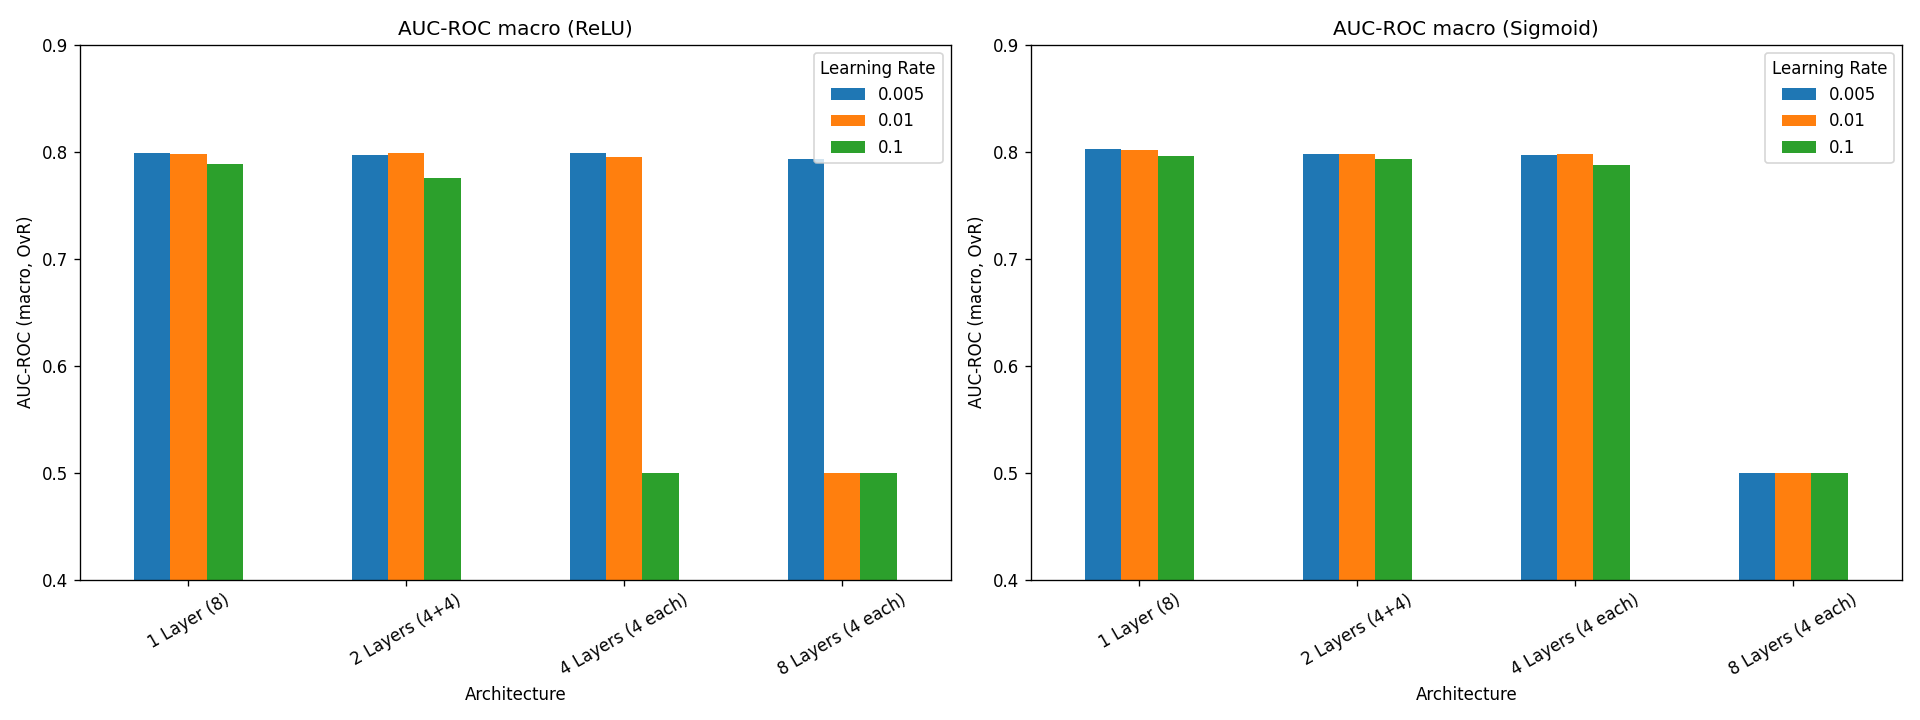

In [44]:
import matplotlib.pyplot as plt

activation_labels = {'relu': 'ReLU', 'sigmoid': 'Sigmoid'}

architecture_labels_en = {
    "1 שכבה - 8 נוירונים": "1 Layer (8)",
    "2 שכבות - 4+4 נוירונים": "2 Layers (4+4)",
    "4 שכבות - 4 נוירונים כל שכבה": "4 Layers (4 each)",
    "8 שכבות - 4 נוירונים כל שכבה": "8 Layers (4 each)",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for act_name, ax in zip(['relu', 'sigmoid'], axes):
    subset = results_df[results_df['activation'] == act_name]
    pivot = subset.pivot(index='architecture', columns='learning_rate', values='AUC_ROC_macro')
    pivot = pivot.reindex([a[0] for a in architectures])
    pivot = pivot.rename(index=architecture_labels_en)
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'AUC-ROC macro ({activation_labels[act_name]})')
    ax.set_ylabel('AUC-ROC (macro, OvR)')
    ax.set_xlabel('Architecture')
    ax.set_ylim(0.4, 0.9)
    ax.legend(title='Learning Rate')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('auc_comparison.png', dpi=120)
plt.show()


## 9. ניתוח התוצאות

**עדכון**: הבעיה שונתה מקלסיפיקציה בינארית (חציון) לקלסיפיקציה מרובת-מחלקות (שלישונים: short/medium/long). המדדים (AUC-ROC, F1, Precision, Recall) מחושבים כעת בגישת **macro-average** — ממוצע לא-משוקלל על פני שלוש המחלקות, כך שכל קטגוריה (כולל 'medium', שהיא לרוב הקשה ביותר לחיזוי) משפיעה באותה מידה על הציון.

**ממצא מרכזי — קריסת רשתות עמוקות (Vanishing Gradient):**

כמו בגרסה הבינארית, הרשתות בעלות **8 שכבות חבויות** צפויות לקרוס בחלק ניכר מהקומבינציות (AUC≈0.5, המקביל לניחוש אקראי גם ב-multi-class). זו תופעה מוכרת ברשתות נוירונים עמוקות ללא מנגנוני ייצוב: הגרדיאנט 'נעלם' ככל שהוא מתפשט אחורה דרך שכבות רבות, במיוחד עם Sigmoid.

**מגמות נוספות צפויות:**
- הפרדה בין 'קצר' ל'ארוך' צפויה להיות קלה יחסית למודל, בעוד הקטגוריה 'בינוני' (medium) — שגובלת בשתי הקטגוריות האחרות — צפויה להיות המאתגרת ביותר לסיווג, ולהוריד את ה-F1/Recall הממוצע (macro) יחסית לבעיה הבינארית.
- הרשתות הרדודות יותר (1–2 שכבות) צפויות להניב את התוצאות היציבות ביותר, בדומה למגמה שנצפתה בגרסה הבינארית.

**מסקנה תפעולית**: מודל תלת-קטגורי נותן לצוות המיון רזולוציה גבוהה יותר להחלטה תפעולית (לא רק 'קצר/ארוך' אלא גם זיהוי 'טווח ביניים'), במחיר קושי חיזוי גבוה יותר סביב גבולות הקטגוריות.

## 10. נספח — גרסה מקבילה עם Keras/TensorFlow (אופציונלי)

אם ה-Colab שלכם כולל TensorFlow (ברוב המקרים כן, כברירת מחדל), ניתן להריץ את אותו גריד באמצעות Keras במקום `MLPClassifier`. הקוד הבא מדגים ריצה בודדת (ארכיטקטורה + היפרפרמטר אחד) — ניתן לעטוף אותו באותה לולאה משולשת כמו בסעיף 7 כדי לקבל את כל 24 הקומבינציות.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_keras_model(hidden_layers, activation, learning_rate, input_dim):
    model = Sequential()
    model.add(Dense(hidden_layers[0], activation=activation, input_dim=input_dim))
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
    model.add(Dense(1, activation='sigmoid'))  # output layer for binary classification
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',   # cross-entropy loss
        metrics=['accuracy']
    )
    return model

# דוגמה: ארכיטקטורה 2 שכבות (4,4), activation=relu, lr=0.01
keras_model = build_keras_model(
    hidden_layers=(4, 4),
    activation='relu',
    learning_rate=0.01,
    input_dim=X_train_encoded.shape[1]
)

history = keras_model.fit(
    X_train_encoded.toarray() if hasattr(X_train_encoded, 'toarray') else X_train_encoded,
    y_train,
    epochs=30,
    batch_size=64,
    verbose=0,
    validation_split=0.1
)

from sklearn.metrics import roc_auc_score, f1_score
X_test_dense = X_test_encoded.toarray() if hasattr(X_test_encoded, 'toarray') else X_test_encoded
keras_probs = keras_model.predict(X_test_dense, verbose=0).ravel()
keras_preds = (keras_probs >= 0.5).astype(int)

print("Keras model - AUC:", roc_auc_score(y_test, keras_probs))
print("Keras model - F1:", f1_score(y_test, keras_preds))
